# Smart Irrigation Requirement Prediction

This notebook builds a classification workflow for estimating whether irrigation is required from farm sensor readings.

## Workflow

- Load the local smart farming sensor dataset
- Build an `irrigation_required` target from moisture, rainfall, humidity, temperature, sunlight, and vegetation index
- Train SVM, KNN, and CatBoost classifiers
- Compare the models with accuracy, precision, recall, and F1-score
- Review the features that drive the selected model

In [18]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

## Load Data

In [19]:
DATA_PATH = 'data/smart_farming_sensor_data.csv'

farm_data = pd.read_csv(DATA_PATH)
farm_data.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe


In [20]:
farm_data.shape

(500, 22)

In [21]:
farm_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               500 non-null    object 
 1   region                500 non-null    object 
 2   crop_type             500 non-null    object 
 3   soil_moisture_%       500 non-null    float64
 4   soil_pH               500 non-null    float64
 5   temperature_C         500 non-null    float64
 6   rainfall_mm           500 non-null    float64
 7   humidity_%            500 non-null    float64
 8   sunlight_hours        500 non-null    float64
 9   irrigation_type       350 non-null    object 
 10  fertilizer_type       500 non-null    object 
 11  pesticide_usage_ml    500 non-null    float64
 12  sowing_date           500 non-null    object 
 13  harvest_date          500 non-null    object 
 14  total_days            500 non-null    int64  
 15  yield_kg_per_hectare  5

## Sensor Features

In [22]:
sensor_features = [
    'soil_moisture_%',
    'temperature_C',
    'rainfall_mm',
    'humidity_%',
    'sunlight_hours',
    'NDVI_index',
]

farm_data[sensor_features].describe().T

,count,mean,std,min,25%,50%,75%,max
soil_moisture_%,500.0,26.75014,10.150053,10.16,17.8900,25.855,36.0225,44.98
temperature_C,500.0,24.67574,5.348899,15.00,20.2950,24.655,29.0900,34.84
rainfall_mm,500.0,181.68574,72.293091,50.17,119.2175,191.545,239.0350,298.96
humidity_%,500.0,65.19446,14.642849,40.23,51.8650,65.685,77.9950,90.00
sunlight_hours,500.0,7.03014,1.691670,4.01,5.6675,6.995,8.4700,10.00
NDVI_index,500.0,0.60206,0.175402,0.30,0.4475,0.610,0.7500,0.90


## Build The Irrigation Target

In [23]:
farm_data['water_score'] = (
    (100 - farm_data['soil_moisture_%']) * 0.45
    + farm_data['temperature_C'] * 0.25
    + (100 - farm_data['humidity_%']) * 0.15
    + (100 - farm_data['rainfall_mm'].clip(upper=100)) * 0.10
    + farm_data['sunlight_hours'] * 0.05
)

score_threshold = farm_data['water_score'].median()
farm_data['irrigation_required'] = (farm_data['water_score'] > score_threshold).astype(int)

farm_data[sensor_features + ['water_score', 'irrigation_required']].head()

,soil_moisture_%,temperature_C,rainfall_mm,humidity_%,sunlight_hours,NDVI_index,water_score,irrigation_required
0,35.95,17.79,75.62,77.03,7.27,0.63,39.5170,0
1,19.74,30.18,89.91,61.13,5.67,0.58,50.7850,1
2,29.32,27.37,265.43,68.87,8.23,0.80,43.7295,0
3,17.33,33.73,212.01,70.46,5.03,0.44,50.3165,1
4,19.37,33.86,269.09,55.73,7.93,0.84,51.7855,1


In [24]:
irrigation_counts = farm_data['irrigation_required'].value_counts().sort_index()
irrigation_counts.index = ['Not Required', 'Required']
irrigation_counts

Not Required    250
Required        250
Name: count, dtype: int64

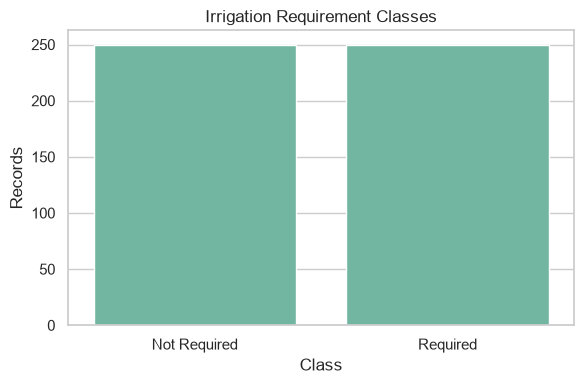

In [25]:
plt.figure(figsize=(6, 4))
sns.barplot(x=irrigation_counts.index, y=irrigation_counts.values)
plt.title('Irrigation Requirement Classes')
plt.ylabel('Records')
plt.xlabel('Class')
plt.tight_layout()
plt.show()

## Feature Patterns

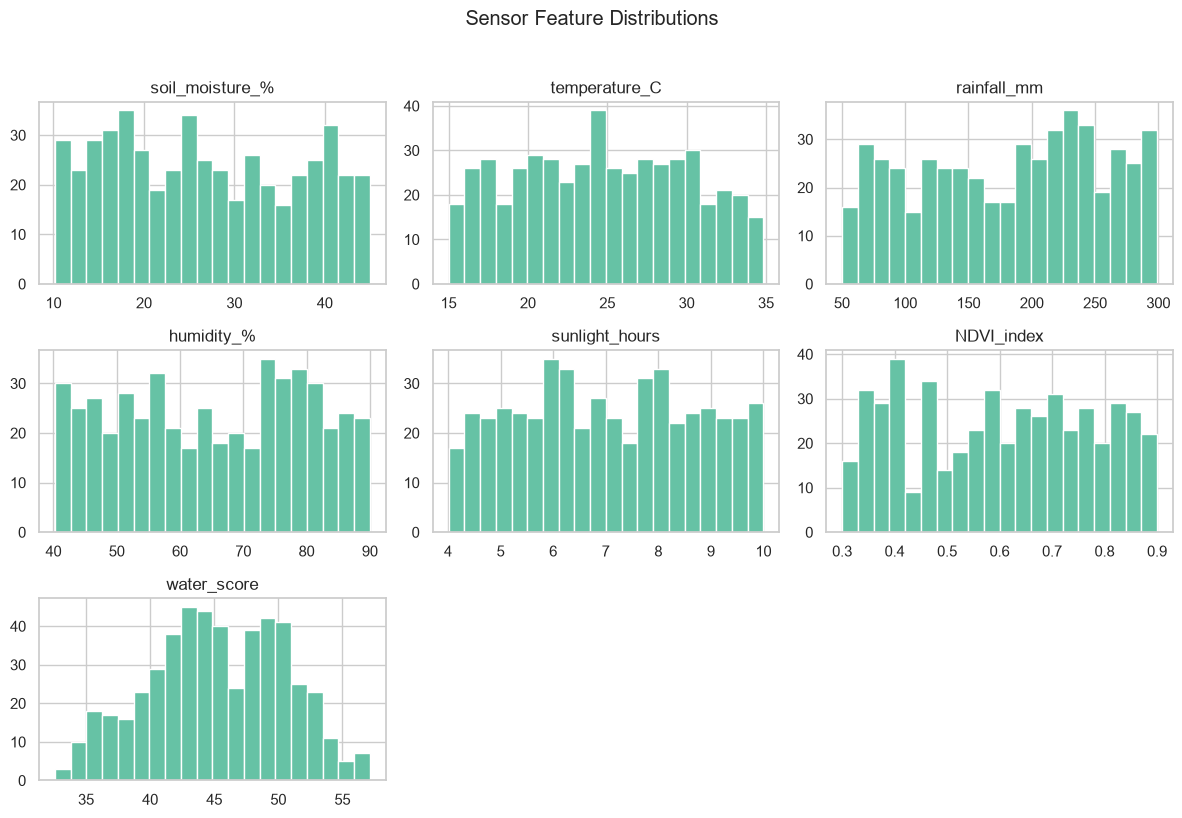

In [26]:
plot_columns = sensor_features + ['water_score']

farm_data[plot_columns].hist(figsize=(12, 8), bins=20)
plt.suptitle('Sensor Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

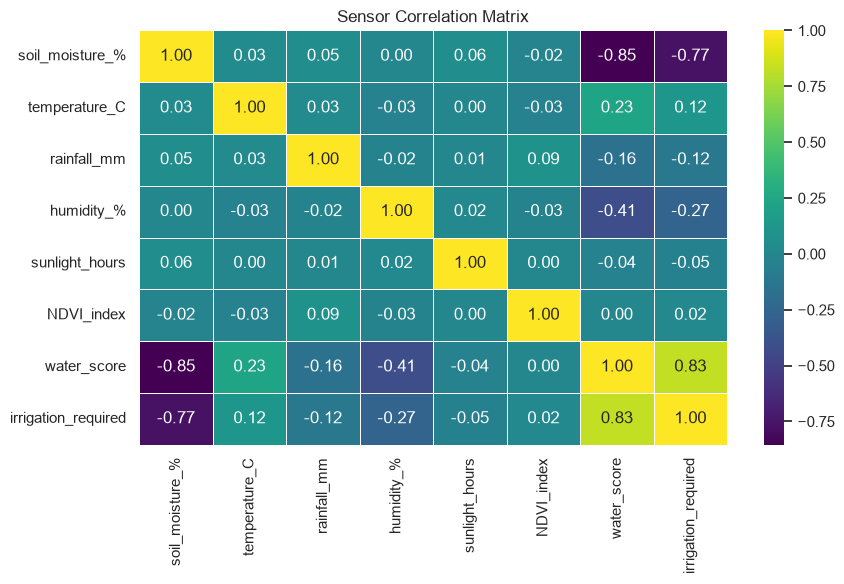

In [27]:
plt.figure(figsize=(9, 6))
correlation_matrix = farm_data[sensor_features + ['water_score', 'irrigation_required']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='viridis', linewidths=0.5)
plt.title('Sensor Correlation Matrix')
plt.tight_layout()
plt.show()

## Train-Test Split

In [28]:
features = farm_data[sensor_features]
target = farm_data['irrigation_required']

training_features, test_features, training_labels, test_labels = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target,
)

training_features.shape, test_features.shape

((400, 6), (100, 6))

## Irrigation Classifier Benchmark

In [29]:
candidate_models = {
    'SVM': Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('model', SVC(kernel='rbf', C=3, gamma='scale', random_state=42)),
        ]
    ),
    'KNN': Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier(n_neighbors=7, weights='distance')),
        ]
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=4,
        loss_function='Logloss',
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    ),
}

model_scores = []
fitted_models = {}

for model_name, model in candidate_models.items():
    model.fit(training_features, training_labels)
    predictions = model.predict(test_features)

    fitted_models[model_name] = model
    model_scores.append(
        {
            'model': model_name,
            'accuracy': accuracy_score(test_labels, predictions),
            'precision': precision_score(test_labels, predictions),
            'recall': recall_score(test_labels, predictions),
            'f1_score': f1_score(test_labels, predictions),
        }
    )

score_table = pd.DataFrame(model_scores).sort_values(
    by=['f1_score', 'accuracy'],
    ascending=False,
).reset_index(drop=True)

score_table

,model,accuracy,precision,recall,f1_score
0,KNN,0.96,0.960000,0.96,0.960000
1,CatBoost,0.95,0.978723,0.92,0.948454
2,SVM,0.91,0.886792,0.94,0.912621


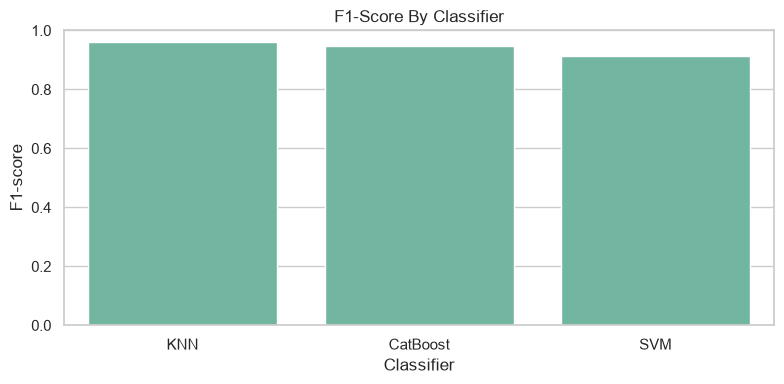

In [30]:
plt.figure(figsize=(8, 4))
sns.barplot(data=score_table, x='model', y='f1_score')
plt.title('F1-Score By Classifier')
plt.ylim(0, 1)
plt.xlabel('Classifier')
plt.ylabel('F1-score')
plt.tight_layout()
plt.show()

## Selected Model

In [31]:
best_model_name = score_table.loc[0, 'model']
best_irrigation_model = fitted_models[best_model_name]
best_predictions = best_irrigation_model.predict(test_features)

print(f'Best model: {best_model_name}')
print(classification_report(test_labels, best_predictions, target_names=['Not Required', 'Required']))

Best model: KNN
              precision    recall  f1-score   support

Not Required       0.96      0.96      0.96        50
    Required       0.96      0.96      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



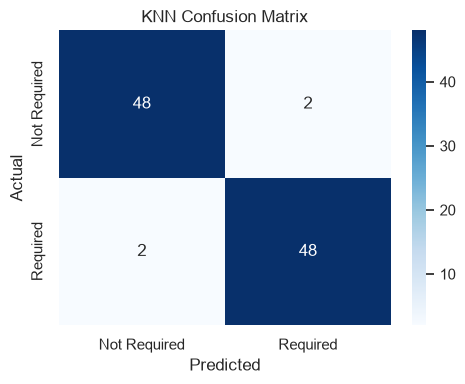

In [32]:
confusion = confusion_matrix(test_labels, best_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Required', 'Required'],
    yticklabels=['Not Required', 'Required'],
)
plt.title(f'{best_model_name} Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Feature Importance

In [33]:
importance_result = permutation_importance(
    best_irrigation_model,
    test_features,
    test_labels,
    n_repeats=10,
    random_state=42,
    scoring='f1',
)

feature_importance = pd.DataFrame(
    {
        'feature': sensor_features,
        'importance': importance_result.importances_mean,
    }
).sort_values('importance', ascending=False)

feature_importance

,feature,importance
0,soil_moisture_%,0.426904
3,humidity_%,0.081333
1,temperature_C,0.042729
2,rainfall_mm,0.041426
5,NDVI_index,0.021394
4,sunlight_hours,0.012231


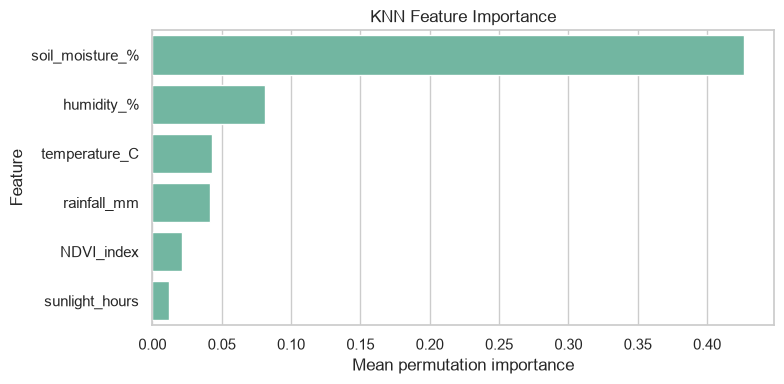

In [34]:
plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title(f'{best_model_name} Feature Importance')
plt.xlabel('Mean permutation importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Sample Prediction

In [35]:
sample_farm = test_features.iloc[[0]]
sample_prediction = best_irrigation_model.predict(sample_farm)[0]
sample_label = 'Irrigation Required' if sample_prediction == 1 else 'No Irrigation Required'

sample_farm.assign(prediction=sample_label)

,soil_moisture_%,temperature_C,rainfall_mm,humidity_%,sunlight_hours,NDVI_index,prediction
177,10.71,21.06,120.09,64.58,8.18,0.35,Irrigation Required


## Takeaway

KNN gave the strongest test-set F1-score in this run, with CatBoost close behind. Soil moisture, humidity, rainfall, and temperature are the main signals because they directly describe how dry or stressed the farm conditions are.